# RGB to Grayscale Conversion (CUDA)

This notebook demonstrates **image color-to-grayscale conversion on the GPU**.

We convert an RGB image to grayscale using the luminosity formula:

**Gray = 0.21R + 0.72G + 0.07B**

The workflow follows the typical CUDA pattern:
1. Load the image and extract RGB pixel data on the host
2. Allocate memory on the device
3. Copy input data from host to device
4. Launch the kernel
5. Copy the result back from device to host
6. Free device memory and save the output image

In [15]:
!apt update -qq && apt install -y -qq nvidia-cuda-toolkit

56 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
nvidia-cuda-toolkit is already the newest version (11.5.1-1ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 56 not upgraded.


## The Kernel and `colorToGrayscale` Function

- **`colorToGrayscaleKernel`** — a CUDA kernel that runs on the GPU. Each thread converts one pixel from RGB to grayscale using the weighted sum `0.21R + 0.72G + 0.07B`. The 2D thread indexing maps directly to image rows and columns.
- **`colorToGrayscale`** — the host function that orchestrates the GPU computation: allocates device memory, copies data host→device, launches the kernel, copies the result device→host, and frees device memory.
- **2D grid/block layout** — we use a 16×16 thread block to match the 2D nature of images, and compute the grid dimensions so every pixel is covered.

In [16]:
%%writefile grayscale.cu
#include <stdio.h>
#include <stdlib.h>

#define STB_IMAGE_IMPLEMENTATION
#include "stb_image.h"
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image_write.h"

#define CUDA_CHECK(call)                                                       \
    do {                                                                       \
        cudaError_t err = (call);                                              \
        if (err != cudaSuccess) {                                              \
            fprintf(stderr, "CUDA error at %s:%d - %s\n", __FILE__, __LINE__, \
                    cudaGetErrorString(err));                                   \
            exit(EXIT_FAILURE);                                                \
        }                                                                      \
    } while (0)

__global__ void colorToGrayscaleKernel(unsigned char* Pin, unsigned char* Pout,
                                       int width, int height) {
    int col = blockDim.x * blockIdx.x + threadIdx.x;
    int row = blockDim.y * blockIdx.y + threadIdx.y;

    if (col < width && row < height) {
        int grayOffset = row * width + col;
        int rgbOffset = grayOffset * 3;

        unsigned char r = Pin[rgbOffset];
        unsigned char g = Pin[rgbOffset + 1];
        unsigned char b = Pin[rgbOffset + 2];

        Pout[grayOffset] = (unsigned char)(0.21f * r + 0.72f * g + 0.07f * b);
    }
}

void colorToGrayscale(unsigned char* Pin_h, unsigned char* Pout_h,
                      int width, int height) {
    int rgbSize = width * height * 3 * sizeof(unsigned char);
    int graySize = width * height * sizeof(unsigned char);
    unsigned char *Pin_d, *Pout_d;

    // Allocate memory on the device
    CUDA_CHECK(cudaMalloc((void**)&Pin_d, rgbSize));
    CUDA_CHECK(cudaMalloc((void**)&Pout_d, graySize));

    // Copy input image from host to device
    CUDA_CHECK(cudaMemcpy(Pin_d, Pin_h, rgbSize, cudaMemcpyHostToDevice));

    // Launch the kernel with 2D grid and block
    dim3 blockDim(16, 16);
    dim3 gridDim((width + blockDim.x - 1) / blockDim.x,
                 (height + blockDim.y - 1) / blockDim.y);
    colorToGrayscaleKernel<<<gridDim, blockDim>>>(Pin_d, Pout_d, width, height);

    // Copy result from device to host
    CUDA_CHECK(cudaMemcpy(Pout_h, Pout_d, graySize, cudaMemcpyDeviceToHost));

    // Free memory on the device
    CUDA_CHECK(cudaFree(Pin_d));
    CUDA_CHECK(cudaFree(Pout_d));
}

int main() {
    int width, height, channels;
    unsigned char* img = stbi_load("input.png", &width, &height, &channels, 3);
    if (!img) {
        fprintf(stderr, "Error: could not load image\n");
        return 1;
    }
    printf("Loaded image: %d x %d (%d channels)\n", width, height, channels);

    unsigned char* grayImg = new unsigned char[width * height];

    colorToGrayscale(img, grayImg, width, height);

    stbi_write_png("output.png", width, height, 1, grayImg, width);
    printf("Grayscale image saved to output.png\n");

    delete[] grayImg;
    stbi_image_free(img);

    return 0;
}

Overwriting grayscale.cu


## Download stb Libraries

We use [stb_image](https://github.com/nothings/stb) for loading and saving images — single-header libraries that require no external dependencies.

In [17]:
!curl -sO https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
!curl -sO https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h
!ls -lh stb_image*.h

-rw-r--r-- 1 root root 277K Mar 26 02:30 stb_image.h
-rw-r--r-- 1 root root  70K Mar 26 02:30 stb_image_write.h


## Download and Preview the Input Image

Downloads a test image from a URL. You can replace the `url` variable with any image URL.

Input image: 640 x 480


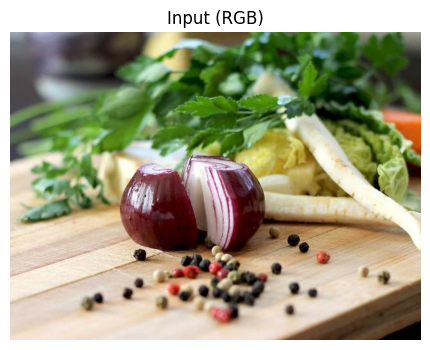

In [18]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# Download a test image from URL
url = "https://picsum.photos/id/292/640/480"
response = requests.get(url)
response.raise_for_status()

# Convert to RGB and save as input.png
img = Image.open(BytesIO(response.content)).convert("RGB")
img.save("input.png")
print(f"Input image: {img.size[0]} x {img.size[1]}")

plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.title("Input (RGB)")
plt.axis("off")
plt.show()

## Compile and Run

In [19]:
!nvcc grayscale.cu -o grayscale && ./grayscale

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
stb_image.h(4276): warning #550-D: variable "old_limit" was set but never used
     unsigned int cur, limit, old_limit;
                              ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

stb_image.h(5185): warning #550-D: variable "idata_limit_old" was set but never used
                 stbi__uint32 idata_limit_old = idata_limit;
                              ^

stb_image.h(6972): warning #550-D: variable "out_size" was set but never used
        int out_size = 0;
            ^

stb_image.h(6973): warning #550-D: variable "delays_size" was set but never used
        int delays_size = 0;
            ^

Loaded image: 640 x 480 (3 channels)
Grayscale image saved to output.png


## Verify the Output

Display the input and output images side by side.

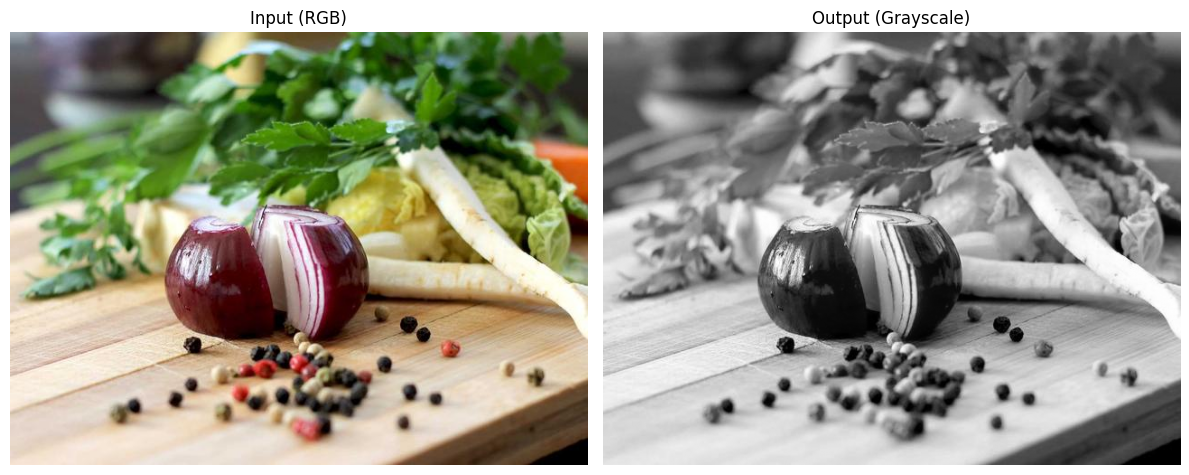

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

input_img = Image.open("input.png")
output_img = Image.open("output.png")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(input_img)
ax1.set_title("Input (RGB)")
ax1.axis("off")
ax2.imshow(output_img, cmap="gray")
ax2.set_title("Output (Grayscale)")
ax2.axis("off")
plt.tight_layout()
plt.show()

## Code Walkthrough

### Error-checking macro

```c
#define CUDA_CHECK(call)                                                       \
    do {                                                                       \
        cudaError_t err = (call);                                              \
        if (err != cudaSuccess) {                                              \
            fprintf(stderr, "CUDA error at %s:%d - %s\n", __FILE__, __LINE__, \
                    cudaGetErrorString(err));                                   \
            exit(EXIT_FAILURE);                                                \
        }                                                                      \
    } while (0)
```

Same pattern as vector addition — wraps every CUDA API call and aborts with a descriptive message on failure.

### The kernel

```c
__global__ void colorToGrayscaleKernel(unsigned char* Pin, unsigned char* Pout,
                                       int width, int height) {
    int col = blockDim.x * blockIdx.x + threadIdx.x;
    int row = blockDim.y * blockIdx.y + threadIdx.y;

    if (col < width && row < height) {
        int grayOffset = row * width + col;
        int rgbOffset = grayOffset * 3;

        unsigned char r = Pin[rgbOffset];
        unsigned char g = Pin[rgbOffset + 1];
        unsigned char b = Pin[rgbOffset + 2];

        Pout[grayOffset] = (unsigned char)(0.21f * r + 0.72f * g + 0.07f * b);
    }
}
```

- **2D thread indexing** — unlike vector addition which used 1D indexing (`blockDim.x * blockIdx.x + threadIdx.x`), this kernel uses **two dimensions** to match the row/column structure of an image. `col` maps to the x-axis (width) and `row` maps to the y-axis (height).
- **`grayOffset = row * width + col`** — linearizes the 2D pixel coordinate into a 1D index for the output grayscale array (1 byte per pixel).
- **`rgbOffset = grayOffset * 3`** — the input image stores 3 bytes per pixel (R, G, B), so the RGB data for pixel `(row, col)` starts at index `grayOffset * 3`.
- **`0.21f * r + 0.72f * g + 0.07f * b`** — the **luminosity formula**. Human eyes are most sensitive to green, then red, then blue. These weights produce a perceptually accurate grayscale value.
- **Boundary check** `if (col < width && row < height)` — prevents out-of-bounds access when the grid dimensions exceed the image size.

### The host function

```c
void colorToGrayscale(unsigned char* Pin_h, unsigned char* Pout_h,
                      int width, int height) { ... }
```

Same five-step CUDA workflow as vector addition:

| Step | API Call | Purpose |
|------|----------|---------|
| 1 | `cudaMalloc` | Allocate device memory for input (RGB) and output (gray) |
| 2 | `cudaMemcpy(..., HostToDevice)` | Copy the RGB image to the GPU |
| 3 | `colorToGrayscaleKernel<<<grid, block>>>` | Launch the kernel on the GPU |
| 4 | `cudaMemcpy(..., DeviceToHost)` | Copy the grayscale image back to the CPU |
| 5 | `cudaFree` | Free the device memory |

### Kernel launch configuration

```c
dim3 blockDim(16, 16);
dim3 gridDim((width + blockDim.x - 1) / blockDim.x,
             (height + blockDim.y - 1) / blockDim.y);
```

- **`dim3 blockDim(16, 16)`** — each block contains 16×16 = 256 threads arranged in a 2D grid. This matches the 2D layout of image pixels.
- **`gridDim`** — ceiling division ensures the grid covers every pixel. For a 256×256 image: `gridDim = (16, 16)`, launching `16×16 = 256` blocks × 256 threads/block = 65,536 total threads — exactly one per pixel.

## 1D vs 2D Thread Indexing

In the vector addition kernel, we used **1D indexing**:

```c
// Vector addition (1D)
int i = blockDim.x * blockIdx.x + threadIdx.x;
vecAddKernel<<<ceil(n/256.0), 256>>>(...)
```

For the grayscale kernel, we use **2D indexing**:

```c
// Grayscale (2D)
int col = blockDim.x * blockIdx.x + threadIdx.x;
int row = blockDim.y * blockIdx.y + threadIdx.y;
dim3 blockDim(16, 16);
dim3 gridDim(ceil(width/16.0), ceil(height/16.0));
```

**Why the difference?**

| | Vector Addition | Grayscale |
|---|---|---|
| **Data shape** | 1D array | 2D image (rows × cols) |
| **Indexing** | Single index `i` | Two indices `(row, col)` |
| **Block shape** | 1D: 256 threads | 2D: 16×16 threads |
| **Grid shape** | 1D: `ceil(n/256)` | 2D: `(ceil(W/16), ceil(H/16))` |

CUDA supports up to 3D grids and blocks via `dim3`. Using 2D indexing for images is a natural fit — it maps thread coordinates directly to pixel coordinates, making the code clearer and avoiding manual row/column arithmetic in the index calculation.

**Could we use 1D indexing for images?** Yes — we could flatten the image and use `int i = blockDim.x * blockIdx.x + threadIdx.x`, then derive `row = i / width` and `col = i % width`. The 2D approach avoids these extra divisions and is more readable.